# Working with Sequences

In [6]:
import tensorflow as tf
import matplotlib.pyplot as plt


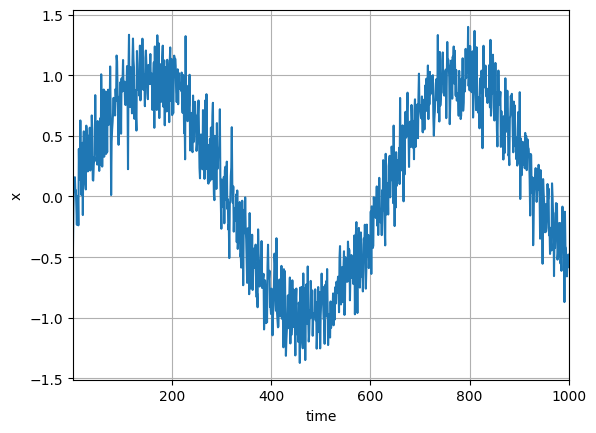

In [7]:
T = 1000
time = tf.range(1, T + 1, dtype=tf.float32)
signal = tf.sin(0.01 * time) + tf.random.normal([T]) * 0.2

plt.plot(time, signal)
plt.xlabel('time')
plt.ylabel('x')
plt.xlim([1, 1000])
plt.figsize=(6, 3)
plt.grid()
plt.show()

In [8]:

tau = 4
num_train = 600
batch_size = 32

# Build features: each row is tau consecutive values, labels are the next value
features = tf.stack([signal[i : T - tau + i] for i in range(tau)], axis=1)  # (T-tau, tau)
labels = tf.reshape(signal[tau:], (-1, 1))                                    # (T-tau, 1)

def get_dataloader(features, labels, num_train, batch_size, train=True):
    i = slice(0, num_train) if train else slice(num_train, None)
    X, y = features[i], labels[i]
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    if train:
        dataset = dataset.shuffle(buffer_size=len(X))
    return dataset.batch(batch_size)

train_loader = get_dataloader(features, labels, num_train, batch_size, train=True)
val_loader   = get_dataloader(features, labels, num_train, batch_size, train=False)

# Sanity check
for X_batch, y_batch in train_loader.take(1):
    print("Feature batch shape:", X_batch.shape)  # (batch_size, tau)
    print("Label batch shape:  ", y_batch.shape)   # (batch_size, 1)


Feature batch shape: (32, 4)
Label batch shape:   (32, 1)


Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6151 - val_loss: 1.2106
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.4809 - val_loss: 1.1124
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3572 - val_loss: 1.0208
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2387 - val_loss: 0.9321
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1305 - val_loss: 0.8476
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0288 - val_loss: 0.7724
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9346 - val_loss: 0.7032
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8488 - val_loss: 0.6366
Epoch 9/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step - loss: 0.7681 - val_loss: 0.5762
Epoch 10/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 926us/step - loss: 0.6940 - val_loss: 0.5231


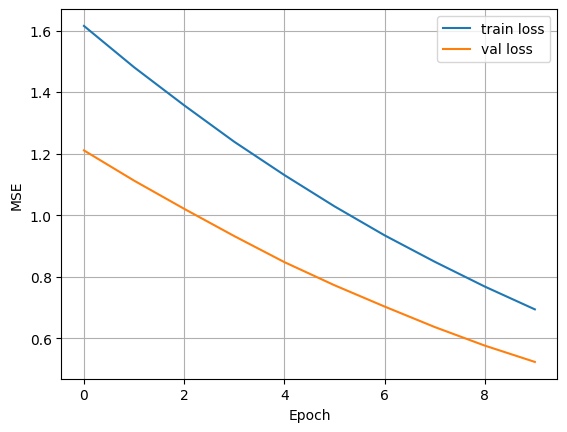

In [9]:
# Linear regression model: output = W*x + b
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=(tau,))
])

model.compile(optimizer='adam', loss='mse')
history = model.fit(train_loader, epochs=10, validation_data=val_loader)

# Plot training vs validation loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid()
plt.show()